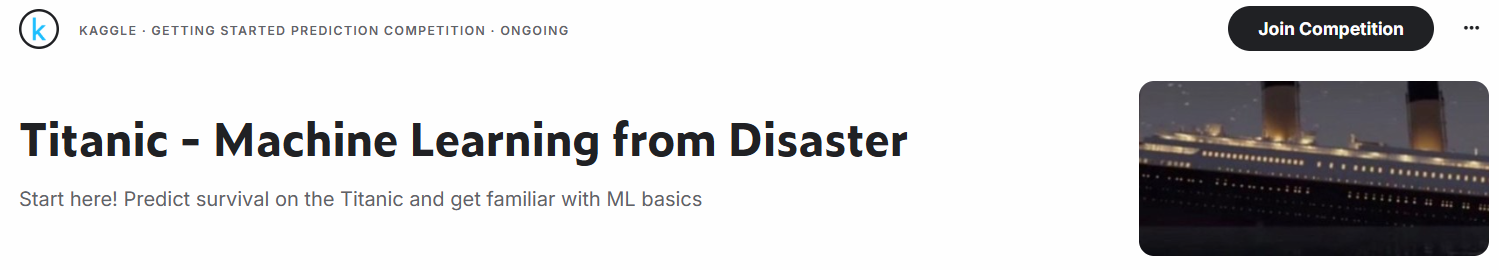
* kaggle : https://www.kaggle.com/competitions/titanic

<pre>survival	0 = No, 1 = Yes
pclass	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd
sex	Sex	
Age	Age in years	
sibsp	# of siblings / spouses aboard the Titanic	
parch	# of parents / children aboard the Titanic	
ticket	Ticket number	
fare	Passenger fare	
cabin	Cabin number	
embarked	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton

In [108]:
from sklearn import set_config
set_config(display="text")
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

import warnings
warnings.filterwarnings('ignore')

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

from sklearn.model_selection import train_test_split           #---- 문제답 분리

from sklearn.linear_model import LogisticRegression             #---- 분류모델(선형모델)
from sklearn.ensemble import RandomForestClassifier             #---- 분류모델(트리모델)   
from sklearn.ensemble import VotingClassifier, VotingRegressor  #---- 분류모델(앙상블)  

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_curve #---- 평가 메트릭스
from sklearn.metrics import roc_auc_score, roc_curve     #---- 평가 메트릭스
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score, cross_validate  #----교차검증

from sklearn.preprocessing import LabelEncoder, OneHotEncoder                       #-----인코딩(글자->숫자변경)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler        #-----정규화(스케일링)
from sklearn.decomposition import PCA                                               #-----차원축소


# **[1] Data Load**

In [109]:
train = pd.read_csv("../datas/titanic/train.csv")   #, parse_dates=['datetime'])
test  = pd.read_csv("../datas/titanic/test.csv") 
sub   = pd.read_csv("../datas/titanic/gender_submission.csv")

* <b>컬럼 이름 소문자

In [110]:
train.columns = train.columns.str.lower()
test.columns  = test.columns.str.lower()

In [111]:
train.shape, test.shape, sub.shape

((891, 12), (418, 11), (418, 2))

## ['passengerid'] 컬럼 삭제

* <b>컬럼 삭제 : passengerid

In [112]:
train = train.drop(columns=['passengerid'])
test  = test.drop(columns=['passengerid'])

# train = train.drop(['dd'], axis=1)    #---칸지우기
# test  = test.drop(['dd'], axis=1)    #---칸지우기

In [113]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C


In [114]:
test.head(2)

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [115]:
sub.head(2)

,PassengerId,Survived
0,892,0
1,893,1


In [116]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   name      891 non-null    str    
 3   sex       891 non-null    str    
 4   age       714 non-null    float64
 5   sibsp     891 non-null    int64  
 6   parch     891 non-null    int64  
 7   ticket    891 non-null    str    
 8   fare      891 non-null    float64
 9   cabin     204 non-null    str    
 10  embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 76.7 KB


In [117]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    418 non-null    int64  
 1   name      418 non-null    str    
 2   sex       418 non-null    str    
 3   age       332 non-null    float64
 4   sibsp     418 non-null    int64  
 5   parch     418 non-null    int64  
 6   ticket    418 non-null    str    
 7   fare      417 non-null    float64
 8   cabin     91 non-null     str    
 9   embarked  418 non-null    str    
dtypes: float64(2), int64(3), str(5)
memory usage: 32.8 KB


* <font color=red><b>결측있다 --> 보간
* <font color=red><b>글자있다 --> 인코딩

# **[2] 1차 EDA(Exploratory Data Analysis)**

## hist() : 데이터 분포도(왜도,첨도,정규분포)

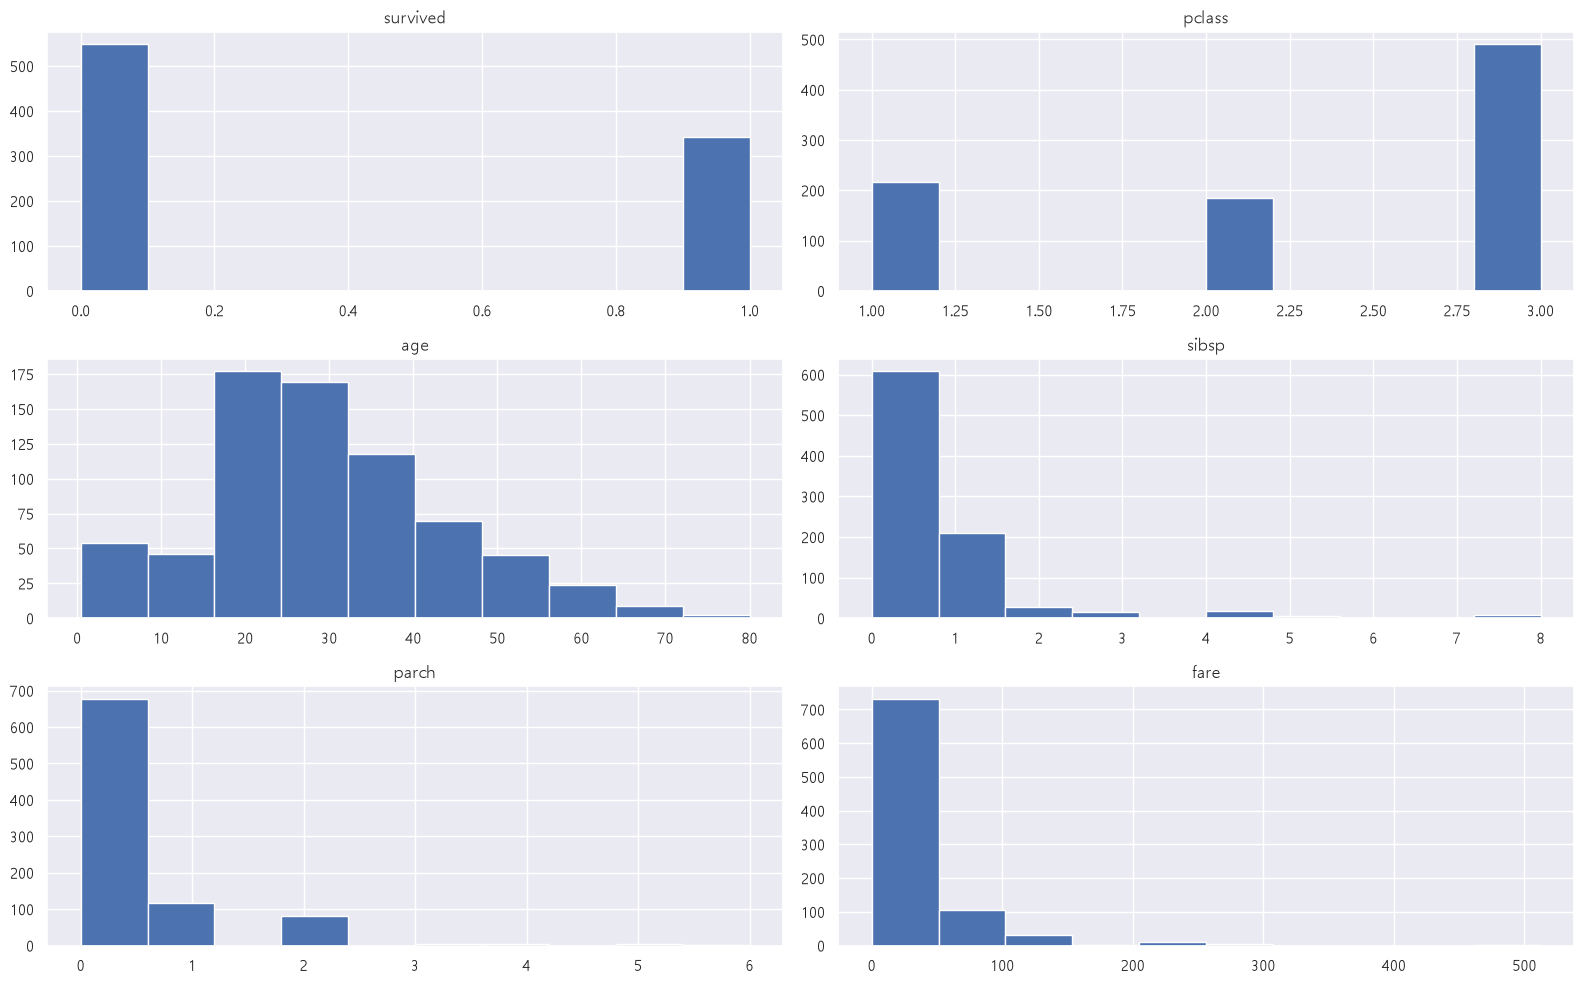

In [118]:
train.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

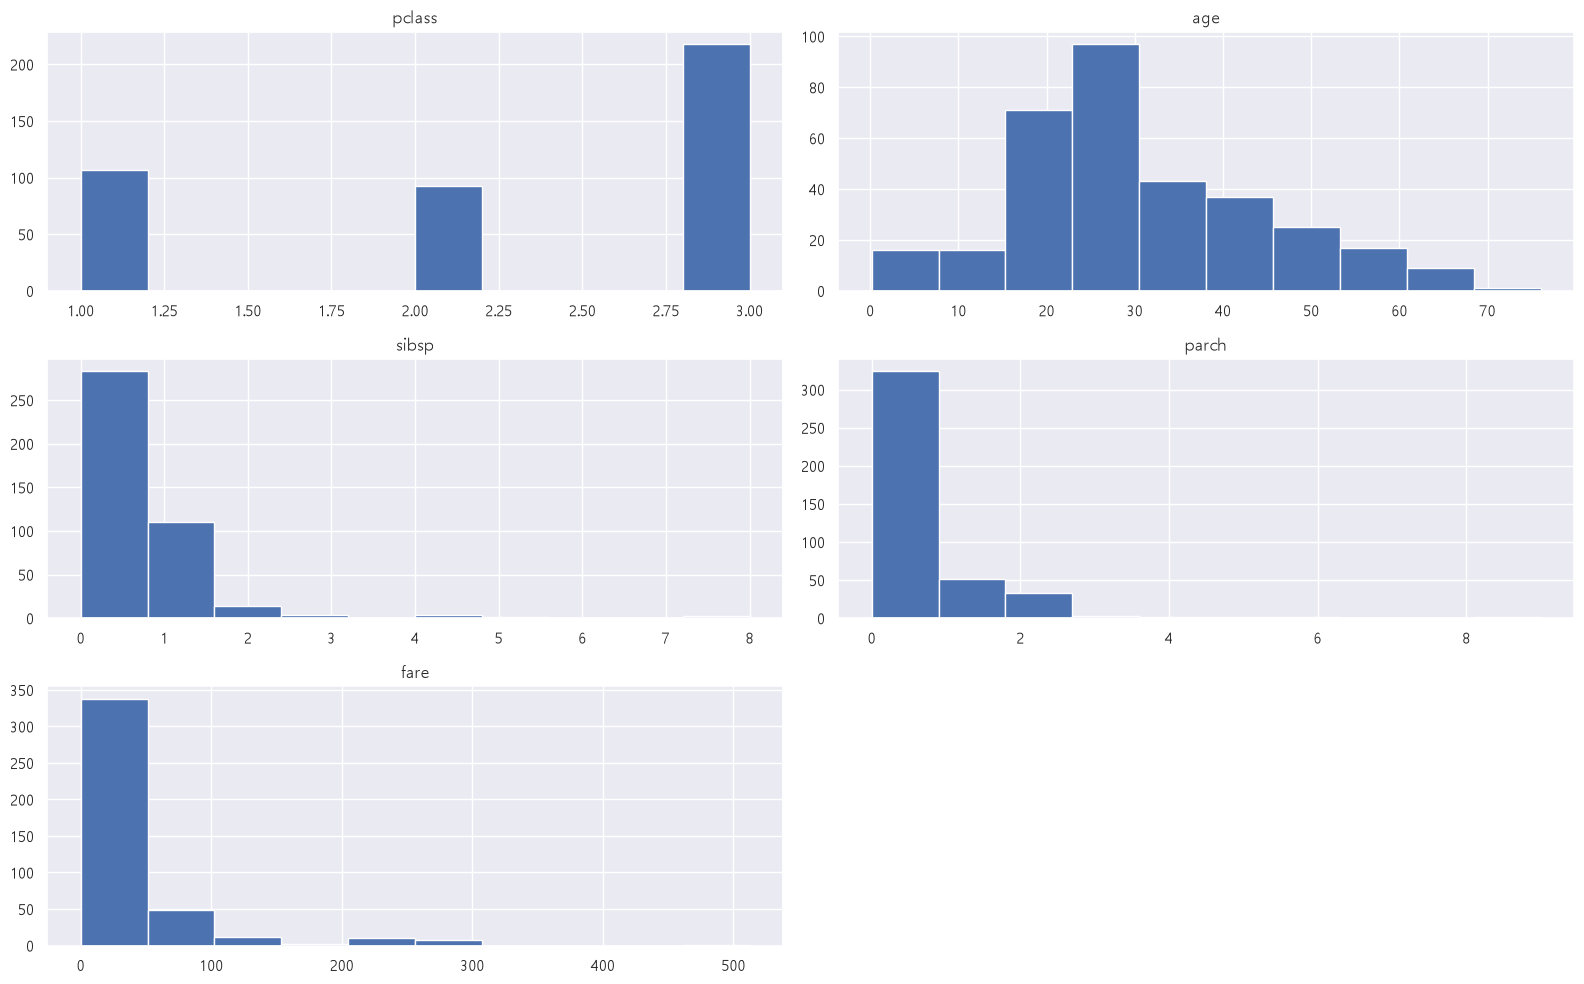

In [119]:
test.hist(figsize=(16,10))
plt.tight_layout()
plt.show()

# **[3] 전처리 & 가공**

* 인코딩
    * sex : male(0), female(1) 
    * embarked : S(0) C(1) Q(2) 
* 결측처리
    * age - 평균
    * cabin - 삭제
    * embarked - 최빈도
    * fare (test)
* 파생피쳐
    * family_cnt = sibsp + parch + 1
    * age_group(나이대)
    * fare_rate(두당 요금)
* name : 호칭분류
* cabin : pclass , fare , fare_rate 와의 관계 -- EDA

## **인코딩** : sex, embarked
* 글자 -> 숫자 변환
* 범주형(카테고리형) 데이터를 숫자로 변환
    * 예) 상중하, ABC , 대중소

### **방법1) map()**

In [120]:
traincp = train.copy()
traincp['sex1'] = traincp['sex'].map({"male":0, "female":1})
traincp.head(1)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,sex1
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,0


### **방법2) replace()**

In [121]:
traincp = train.copy()
traincp['sex1'] = traincp['sex'].replace(["male","female"], [0,1])
traincp.head(1)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,sex1
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,0


### **방법3) apply(lambda x :)**

In [122]:
traincp = train.copy()
traincp["sex1"] = traincp["sex"].apply(lambda s : 0 if s == 'male'  else 1)
traincp.head(1)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,sex1
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,0


### **방법4) LabelEncoder()**
* https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html#sklearn.preprocessing.LabelEncoder

In [123]:
traincp = train.copy()
le = LabelEncoder()
le.fit(traincp['sex'])
traincp['sex1'] = le.transform(traincp['sex'])
traincp.head(1)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,sex1
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.25,NaN,S,1


### **방법5) OneHotEncoder()**
* <font color=red><b>2D만 fit() 가능

In [124]:
traincp = train.copy()
oh = OneHotEncoder(sparse_output=False, dtype=int) 
oh.fit(traincp[['sex']])  #---------------------2차만 가능 주의주의주의
res = oh.transform(traincp[['sex']])
res

array([[0, 1],
       [1, 0],
       [1, 0],
       ...,
       [1, 0],
       [0, 1],
       [0, 1]], shape=(891, 2))

In [125]:
oh.get_feature_names_out(['sex'])

array(['sex_female', 'sex_male'], dtype=object)

In [126]:
temp = pd.DataFrame(res, columns=oh.get_feature_names_out(['sex']))
print(temp.shape, train.shape)
temp.head(2)

(891, 2) (891, 11)


,sex_female,sex_male
0,0,1
1,1,0


In [127]:
traincp = pd.concat([traincp, temp], axis=1)
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,sex_female,sex_male
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,0


### **방법6) pd.get_dummies()**

In [128]:
traincp = train.copy()
traincp = pd.get_dummies(traincp, columns=['sex'], dtype=int)
traincp.head(3)

,survived,pclass,name,age,sibsp,parch,ticket,fare,cabin,embarked,sex_female,sex_male
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,C,1,0
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,0


### **원본적용**

In [129]:
train['sex'] = train['sex'].map({"male":0, "female":1})
test['sex']  = test['sex'].map({"male":0, "female":1})

In [130]:
train['embarked'] = train['embarked'].map({"S":0, "C":1, "Q":2})
test['embarked']  = test['embarked'].map({"S":0, "C":1, "Q":2})

In [131]:
train.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,1.0


## **호칭정리**
* ", ____. "
* .extract(r',\s(\w+)\.')

In [132]:
traincp = train.copy()
testcp = test.copy()
traincp['name'] = traincp['name'].str.extract(r', (.*?)\.')
testcp['name']  = testcp['name'].str.extract(r', (.*?)\.')
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,Mr,0,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,1,1,Mrs,1,38.0,1,0,PC 17599,71.2833,C85,1.0


In [133]:
traincp['name'].value_counts()

name
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [134]:
testcp['name'].value_counts()

name
Mr        240
Miss       78
Mrs        72
Master     21
Col         2
Rev         2
Ms          1
Dr          1
Dona        1
Name: count, dtype: int64

In [135]:
mydic = {
    'Mr': 'Mr',
    'Sir': 'Mr',
    'Capt': 'Mr',
    'Jonkheer': 'Mr',
    'Dr': 'Mr',
    'Rev': 'Mr',
    'Major': 'Mr',
    'Col': 'Mr',
    'Don': 'Mr',
    'Mrs': 'Mrs',
    'Mme': 'Mrs',
    'Dona': 'Mrs',
    'Miss': 'Miss',
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Lady': 'Miss',
    'Master': 'Master',
    'the Countess': 'Mr'
}
traincp['name'] = traincp['name'].map(mydic)
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,3,Mr,0,22.0,1,0,A/5 21171,7.2500,NaN,0.0
1,1,1,Mrs,1,38.0,1,0,PC 17599,71.2833,C85,1.0


* **원본에 적용**

In [136]:
# 호칭 자르기
train['name'] = train['name'].str.extract(r', (.*?)\.')
test['name']  = test['name'].str.extract(r', (.*?)\.')

# 호칭 정리
train['name'] = train['name'].map(mydic)
test['name'] = test['name'].map(mydic)

# 인코딩
train['name'] = train['name'].map({"Mr":0, "Miss":1, "Mrs":2, "Master":3})
test['name']  = test['name'].map({"Mr":0, "Miss":1, "Mrs":2, "Master":3})

In [137]:
train['name'].value_counts()

name
0    539
1    186
2    126
3     40
Name: count, dtype: int64

In [138]:
test['name'].value_counts()

name
0    245
1     79
2     73
3     21
Name: count, dtype: int64

In [139]:
train[train['name'].isna()]

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked


In [140]:
test[test['name'].isna()]

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked


## **결측처리**
* age, cabin, embarked, fare(test)

In [141]:
train.isna().sum()

survived      0
pclass        0
name          0
sex           0
age         177
sibsp         0
parch         0
ticket        0
fare          0
cabin       687
embarked      2
dtype: int64

In [142]:
s = train.isna().sum()
s[s > 0]
# train.isna().sum()[ train.isna().sum() > 0 ]

age         177
cabin       687
embarked      2
dtype: int64

### **age** : 호칭별 평균 나이
* transform()
    * train['age'] = np.round(train.groupby("name")['age'].mean(),1)

In [143]:
train['age'] = train['age'].fillna(np.round(  train.groupby("name")['age'].transform('mean')  ,1)  )
test['age']  = test['age'].fillna(np.round(  test.groupby("name")['age'].transform('mean')  ,1)  )

In [144]:
train.isna().sum()

survived      0
pclass        0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          0
cabin       687
embarked      2
dtype: int64

In [145]:
test.isna().sum()

pclass        0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          1
cabin       327
embarked      0
dtype: int64

In [146]:
test[test['fare'].isna()]

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
152,3,0,0,60.5,0,0,3701,NaN,NaN,0


### **cabin, ticket** : 삭제

In [147]:
train['cabin'].value_counts()

cabin
G6             4
C23 C25 C27    4
B96 B98        4
F33            3
E101           3
              ..
E17            1
A24            1
C50            1
B42            1
C148           1
Name: count, Length: 147, dtype: int64

In [148]:
train[['pclass','cabin']].value_counts()

pclass  cabin      
3       G6             4
1       C23 C25 C27    4
        B96 B98        4
2       F33            3
        E101           3
                      ..
1       E17            1
        A24            1
        C50            1
        B42            1
        C148           1
Name: count, Length: 147, dtype: int64

In [149]:
train['ticket'].value_counts()

ticket
347082             7
1601               7
CA. 2343           7
3101295            6
CA 2144            6
                  ..
SOTON/OQ 392076    1
211536             1
112053             1
111369             1
370376             1
Name: count, Length: 681, dtype: int64

In [150]:
train[train['ticket']=='CA 2144']

,survived,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked
59,0,3,3,0,11.0,5,2,CA 2144,46.9,NaN,0.0
71,0,3,1,1,16.0,5,2,CA 2144,46.9,NaN,0.0
386,0,3,3,0,1.0,5,2,CA 2144,46.9,NaN,0.0
480,0,3,3,0,9.0,5,2,CA 2144,46.9,NaN,0.0
678,0,3,2,1,43.0,1,6,CA 2144,46.9,NaN,0.0
683,0,3,0,0,14.0,5,2,CA 2144,46.9,NaN,0.0


### **embarked** : 최빈도
* S(0)로 채우기
* <font color=red><b>mode()는 Series로 값을 돌려줌 --> 정확히 값을 빼시려면 mode().values[0]

In [151]:
train['embarked'].value_counts()

embarked
0.0    644
1.0    168
2.0     77
Name: count, dtype: int64

In [152]:
print( train['embarked'].mode() )

0    0.0
Name: embarked, dtype: float64


In [153]:
print( train['embarked'].mode().values[0] )

0.0


In [154]:
#train['embarked'] = train['embarked'].fillna( 0 )
train['embarked'] = train['embarked'].fillna(  train['embarked'].mode().values[0]  )

In [155]:
train.isna().sum()

survived      0
pclass        0
name          0
sex           0
age           0
sibsp         0
parch         0
ticket        0
fare          0
cabin       687
embarked      0
dtype: int64

## **불피요한 컬럼 삭제**
* ticket, cabin

In [156]:
train = train.drop(columns=['ticket','cabin'])
test  = test.drop(columns=['ticket','cabin'])

In [157]:
train.head(1)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked
0,0,3,0,0,22.0,1,0,7.25,0.0


In [158]:
test.head(1)

,pclass,name,sex,age,sibsp,parch,fare,embarked
0,3,0,0,34.5,0,0,7.8292,2


In [159]:
train.isna().sum()

survived    0
pclass      0
name        0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64

## **파생피쳐**
* 그룹나이(age_group)
* 총가족수(family_cnt)
* 두당요금(fare_rate)

In [160]:
train["age_group"] = train["age"] // 10
train['family_cnt'] = train['sibsp'] + train['parch'] + 1
train['fare_rate']  = train['fare'] / train['family_cnt'] 

In [161]:
test["age_group"] = test["age"] // 10
test['family_cnt'] = test['sibsp'] + test['parch'] + 1
test['fare_rate']  = test['fare'] / test['family_cnt'] 

## **결측처리2차**

### **fare : 평균요금**
* family_cnt == 1
* pclass == 3

In [162]:
test[test['fare'].isna()]

,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate
152,3,0,0,60.5,0,0,NaN,0,6.0,1,NaN


In [163]:
# train['pclass'] == 3
# train['family_cnt'] == 1
#train[(ㅈ) & (ㅈ)][ㅋ]

train[(train['pclass'] == 3) & (train['family_cnt'] == 1)]['fare'].mean()

np.float64(9.272051851851852)

In [164]:
#test['fare'].fillna(9.27)
v = train[(train['pclass'] == 3) & (train['family_cnt'] == 1)]['fare'].mean()
test['fare'] = test['fare'].fillna(v)

In [165]:
test['fare_rate'] = test['fare'] / test['family_cnt']

## **가공처리 후 최종 데이터**

In [166]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   name        891 non-null    int64  
 3   sex         891 non-null    int64  
 4   age         891 non-null    float64
 5   sibsp       891 non-null    int64  
 6   parch       891 non-null    int64  
 7   fare        891 non-null    float64
 8   embarked    891 non-null    float64
 9   age_group   891 non-null    float64
 10  family_cnt  891 non-null    int64  
 11  fare_rate   891 non-null    float64
dtypes: float64(5), int64(7)
memory usage: 83.7 KB


In [167]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      418 non-null    int64  
 1   name        418 non-null    int64  
 2   sex         418 non-null    int64  
 3   age         418 non-null    float64
 4   sibsp       418 non-null    int64  
 5   parch       418 non-null    int64  
 6   fare        418 non-null    float64
 7   embarked    418 non-null    int64  
 8   age_group   418 non-null    float64
 9   family_cnt  418 non-null    int64  
 10  fare_rate   418 non-null    float64
dtypes: float64(4), int64(7)
memory usage: 36.1 KB


# **[4] 1차점수 : 우선 점수만 보자**

## **공통함수**

In [168]:
def myscore(X_train7, y_train7, X_test3, y_test3, model=None) :
    if model is None : 
        #LogisticRegression , RandomForestClassifier
        model =  RandomForestClassifier (
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    
    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred)
    precision = precision_score(y_test3, pred)
    recall    = recall_score(y_test3, pred)    
    print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )
    

In [169]:
def myscore222(df,  model=None, MY_TARGET="survived") :
    X = df.drop(columns=['survived'])
    y = df[MY_TARGET]
    X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234, shuffle=True)

    if model is None : 
        #LogisticRegression , RandomForestClassifier
        model = RandomForestClassifier(
            n_estimators=100,
            random_state=1234
        )
    print(model.__class__.__name__)    

    model.fit(X_train7, y_train7)
    pred = model.predict(X_test3)

    #-------------------------------------------------pred
    acc       = accuracy_score(y_test3, pred)
    f1        = f1_score(y_test3, pred)
    precision = precision_score(y_test3, pred)
    recall    = recall_score(y_test3, pred)    
    print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )
    
    cm = confusion_matrix(y_test3, pred)
    print( cm )
    
    #-------------------------------------------------proba
    proba = model.predict_proba(X_test3)
    proba_p = proba[:,1]
    #print(proba_p)
    
    precision, recall, th = precision_recall_curve(y_test3, proba_p)
    #print(precision, recall, th)
    #print(len(precision), len(recall), len(th))

    plt.figure(figsize=(8,2))
    plt.plot(th, precision[:len(th)], label="precision")
    plt.plot(th, recall[:len(th)], label="recall")
    plt.legend()
    plt.title("precision_reacall_curv")
    plt.show()

    #-------------------------------------------------proba : roc
    roc = roc_auc_score(y_test3, proba_p)
    print( f"roc auc score : {roc:.4f}" )
    fpr, tpr, th = roc_curve(y_test3, proba_p)

    plt.figure(figsize=(8,2))
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("roc_curve")
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR) == recall")
    plt.show()       
    
    return model

RandomForestClassifier
acc : 0.8097  f1 : 0.7463  precision : 0.7576  recall : 0.7353
[[142  24]
 [ 27  75]]


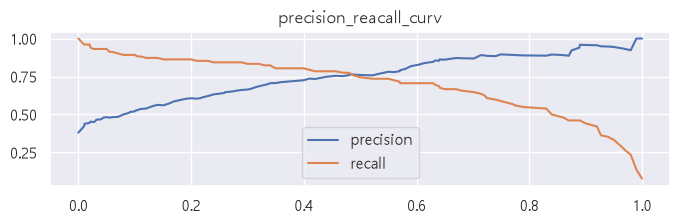

roc auc score : 0.8620


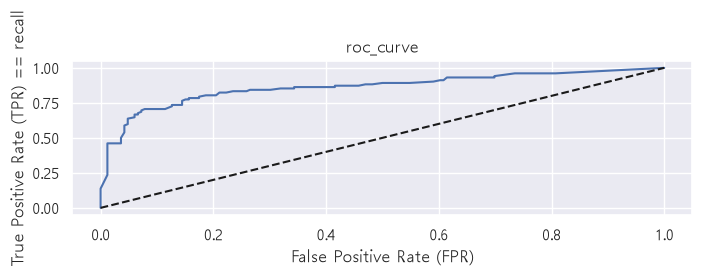

In [170]:
model = myscore222(train)

RandomForestClassifier
acc : 0.8097  f1 : 0.7463  precision : 0.7576  recall : 0.7353
[[142  24]
 [ 27  75]]


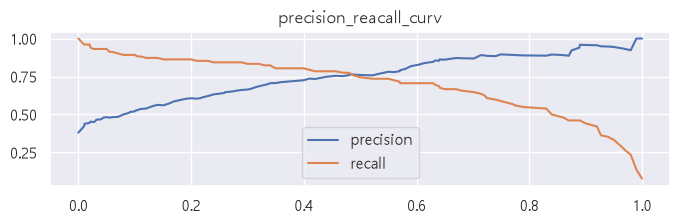

roc auc score : 0.8620


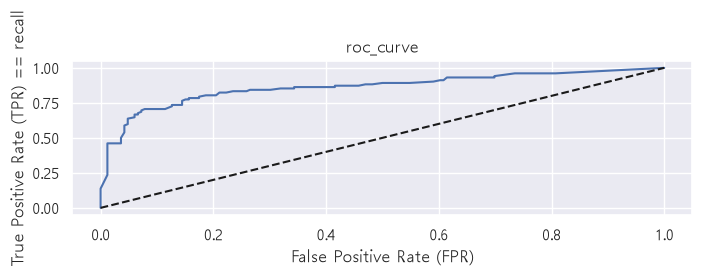

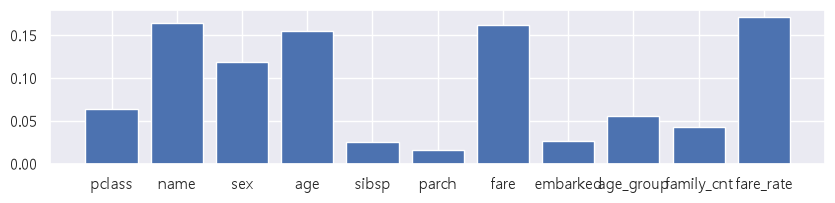

In [171]:
model = myscore222(train)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
plt.bar( test.columns, imp)
plt.show()

In [172]:
# lr = LogisticRegression()
# model2 = myscore222(train, model=lr)

XGBClassifier
acc : 0.8321  f1 : 0.7739  precision : 0.7938  recall : 0.7549
[[146  20]
 [ 25  77]]


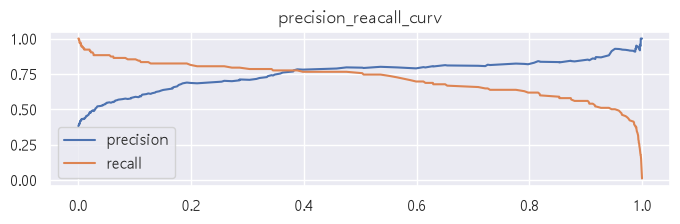

roc auc score : 0.8491


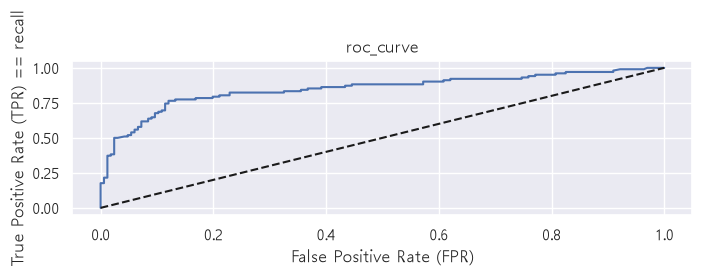

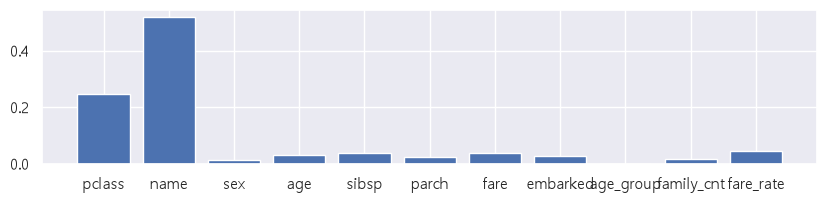

In [173]:
from xgboost import XGBRegressor, XGBClassifier 
#xgb = XGBRegressor()
xgb = XGBClassifier()

model = myscore222(train, xgb)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
plt.bar( test.columns, imp)
plt.show()

LGBMClassifier
[LightGBM] [Info] Number of positive: 240, number of negative: 383
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000138 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 323
[LightGBM] [Info] Number of data points in the train set: 623, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.385233 -> initscore=-0.467396
[LightGBM] [Info] Start training from score -0.467396
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

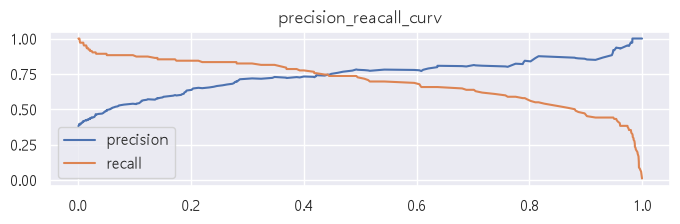

roc auc score : 0.8457


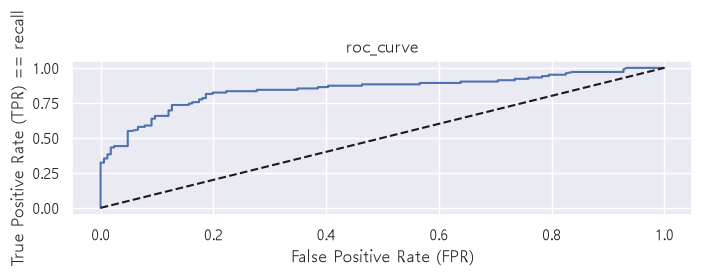

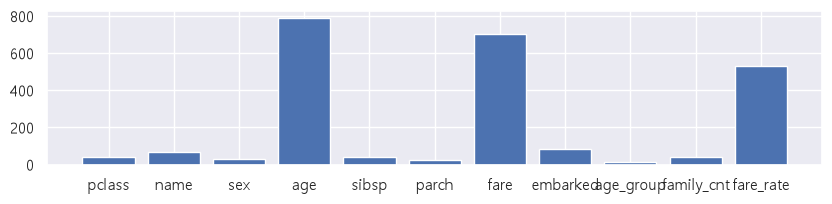

In [174]:
from lightgbm import LGBMRegressor, LGBMClassifier 
lgb = LGBMClassifier()

model = myscore222(train, lgb)
imp = model.feature_importances_
# print(imp)
# print(X_train7.columns)

plt.figure(figsize=(10, 2)) 
plt.bar( test.columns, imp)
plt.show()

# **[5] 2차 EDA(Exploratory Data Analysis)**

## **상관분석** --> 인코딩 처리 후 
* <font color=red><b>두 변수 간의 선형적 관계와 연관성의 강도를 파악하는 통계적 분석 기법
* <font color=red><b>글자피쳐는 상관분석 불가 --> 인코딩 처리 후 분석
* <font color=red><b>피어슨 vs 스피어만
    * 연속형 변수 간의 직선 관계를 보는 피어슨 상관분석과 순위 데이터를 다루는 스피어만 상관분석

### **피어슨 상관분석** : 선형관계

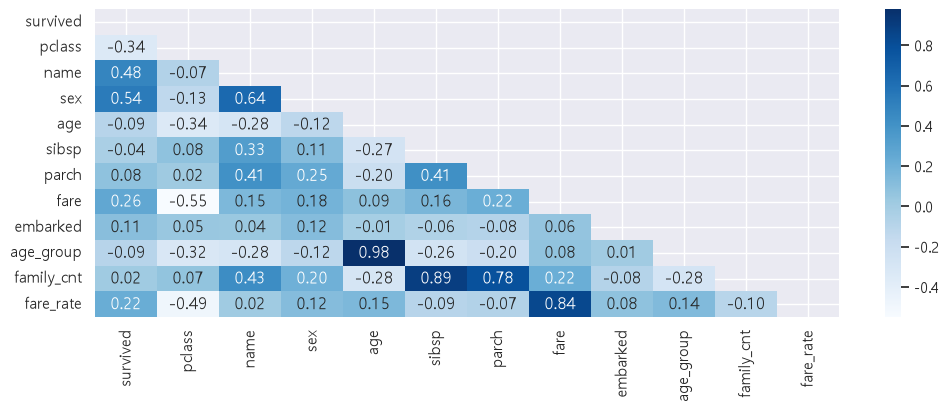

In [175]:
plt.figure(figsize=(12, 4))
# 위쪽 삼각형 가리기
mask = np.triu(np.ones_like(train.corr(), dtype=bool))
sns.heatmap(train.corr(method='pearson'), annot=True, fmt=".2f", cmap="Blues", mask=mask)
plt.show()

### **스피어만 상관분석** 

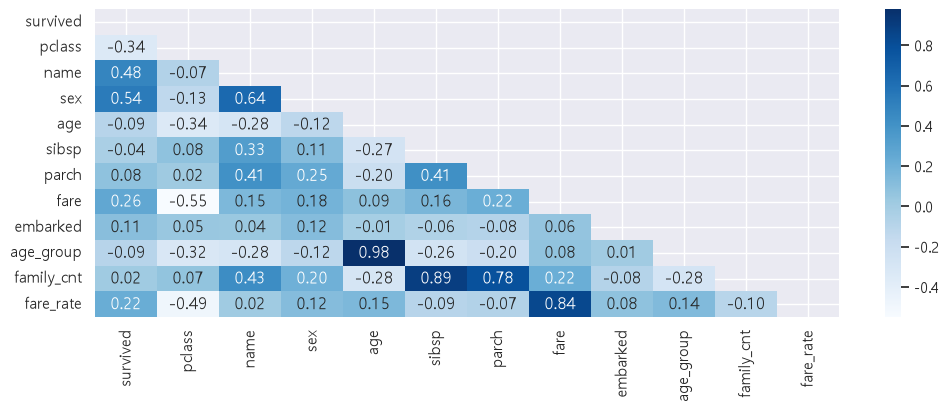

In [176]:
plt.figure(figsize=(12, 4))
# 위쪽 삼각형 가리기
mask = np.triu(np.ones_like(train.corr(method='spearman'), dtype=bool))
sns.heatmap(train.corr(), annot=True, fmt=".2f", cmap="Blues", mask=mask)
plt.show()

## survived

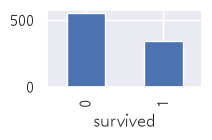

In [177]:
plt.figure(figsize=(2, 1))
train['survived'].value_counts().plot(kind='bar')
plt.show()

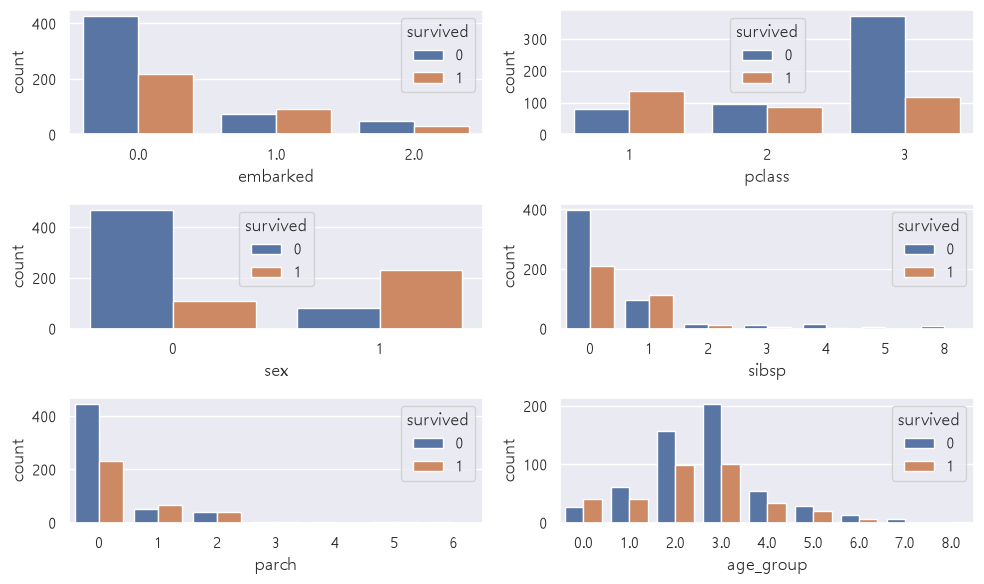

In [178]:
plt.figure(figsize=(10, 6)) 

plt.subplot(3,2,      1)         #---------------------------2행2열의 1번째
sns.countplot(x="embarked", hue="survived", data=train) 

plt.subplot(3,2,      2)         #---------------------------2행2열의 2번째
sns.countplot(x="pclass",   hue="survived", data=train) 

plt.subplot(3,2,      3)         #---------------------------2행2열의 3번째
sns.countplot(x="sex",      hue="survived", data=train) 

#'sibsp', 'parch'
plt.subplot(3,2,      4)         #---------------------------2행2열의 4번째
sns.countplot(x="sibsp",     hue="survived", data=train) 

#'sibsp', 'parch'
plt.subplot(3,2,      5)         #---------------------------2행2열의 4번째
sns.countplot(x="parch",     hue="survived", data=train) 

#'sibsp', 'parch'
#train["age_group"] = train["age"] // 10
plt.subplot(3,2,      6)         #---------------------------2행2열의 4번째
sns.countplot(x="age_group",     hue="survived", data=train) 

plt.tight_layout()
plt.show()

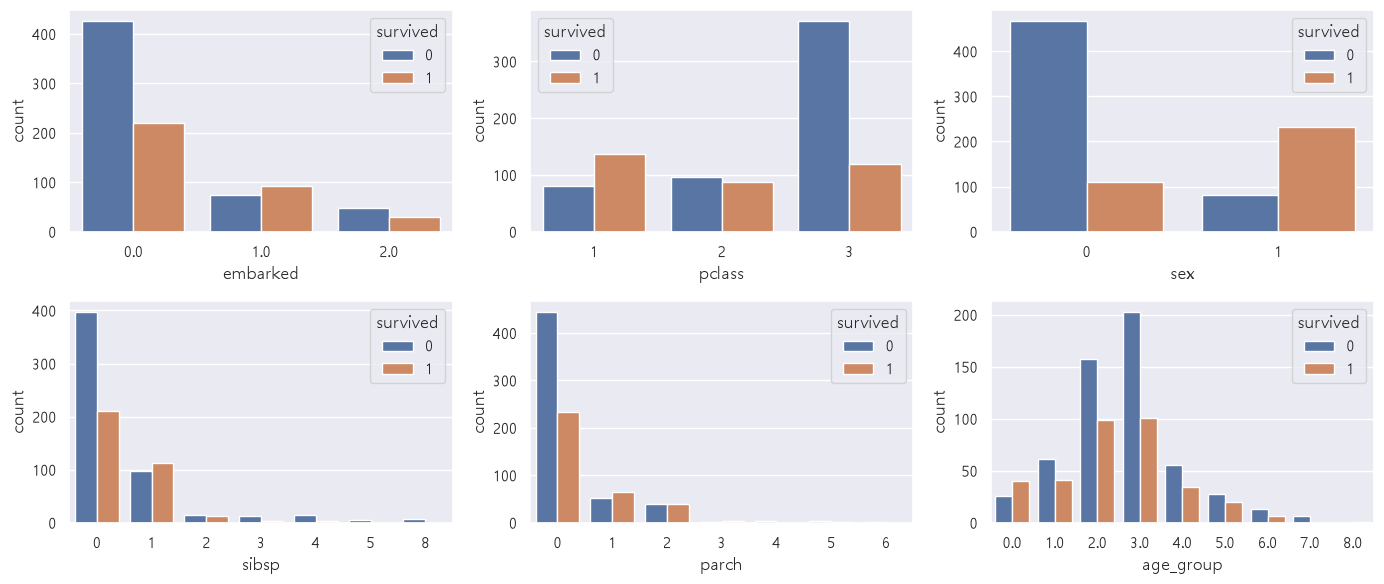

In [179]:
fig, axes = plt.subplots(2,3,     figsize=(14, 6)) 
col_list=[ 'embarked', 'pclass', 'sex', 'sibsp', 'parch', 'age_group']

for i, col in enumerate(col_list) :
    줄=i//3
    칸=i%3
    sns.countplot(x=col, hue="survived", data=train,  ax=axes[줄][칸])

plt.tight_layout()
plt.show()

# **[6] 2차 전처리 & 가공**
* 파생피쳐
* https://www.kaggle.com/code/ldfreeman3/a-data-science-framework-to-achieve-99-accuracy

## **파생피쳐 추가**
* IsAlone : 혼자 여부
* FareBin : 요금 4분위 구간화

In [180]:
train['IsAlone'] = 1 
train['IsAlone'].loc[train['family_cnt'] > 1] = 0 
train['FareBin'] = pd.qcut(train['fare'], 4)

In [181]:
train.head(1)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate,IsAlone,FareBin
0,0,3,0,0,22.0,1,0,7.25,0.0,2.0,2,3.625,1,"(-0.001, 7.91]"


In [182]:
label = LabelEncoder()
train['FareBin'] = label.fit_transform(train['FareBin'])

In [183]:
train.head(3)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate,IsAlone,FareBin
0,0,3,0,0,22.0,1,0,7.2500,0.0,2.0,2,3.62500,1,0
1,1,1,2,1,38.0,1,0,71.2833,1.0,3.0,2,35.64165,1,3
2,1,3,1,1,26.0,0,0,7.9250,0.0,2.0,1,7.92500,1,1


## **2차점수**

* acc : 0.8097
* acc : 0.8284

RandomForestClassifier
acc : 0.8284  f1 : 0.7723  precision : 0.7800  recall : 0.7647
[[144  22]
 [ 24  78]]


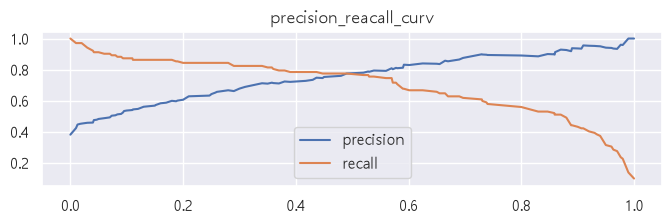

roc auc score : 0.8619


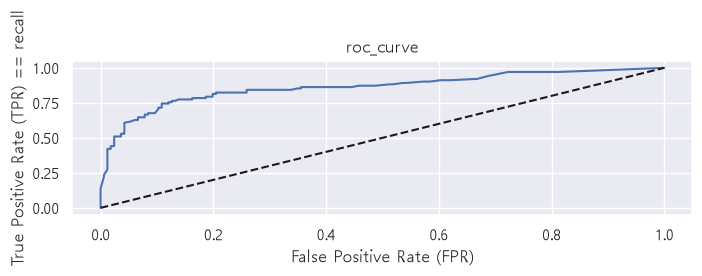

In [184]:
model = myscore222(train)

## **원핫인코딩**
* sex embarked name --> onehot

In [185]:
traincp = train.copy()

In [186]:
traincp.head(2)

,survived,pclass,name,sex,age,sibsp,parch,fare,embarked,age_group,family_cnt,fare_rate,IsAlone,FareBin
0,0,3,0,0,22.0,1,0,7.2500,0.0,2.0,2,3.62500,1,0
1,1,1,2,1,38.0,1,0,71.2833,1.0,3.0,2,35.64165,1,3


In [187]:
#temp = pd.get_dummies(traincp[['sex','embarked','name']])
traincp = pd.get_dummies(traincp, columns=['sex', 'embarked', 'name'])
traincp.head(2)

,survived,pclass,age,sibsp,parch,fare,age_group,family_cnt,fare_rate,IsAlone,FareBin,sex_0,sex_1,embarked_0.0,embarked_1.0,embarked_2.0,name_0,name_1,name_2,name_3
0,0,3,22.0,1,0,7.2500,2.0,2,3.62500,1,0,True,False,True,False,False,True,False,False,False
1,1,1,38.0,1,0,71.2833,3.0,2,35.64165,1,3,False,True,False,True,False,False,False,True,False


## **3차점수**

RandomForestClassifier
acc : 0.8209  f1 : 0.7600  precision : 0.7755  recall : 0.7451
[[144  22]
 [ 26  76]]


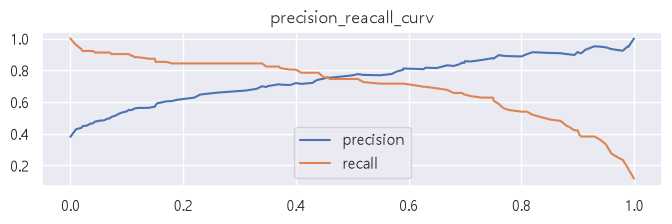

roc auc score : 0.8590


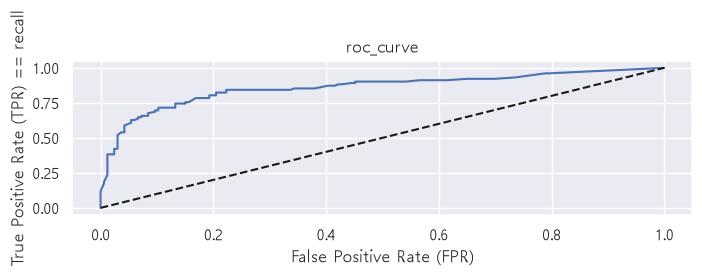

In [188]:
model = myscore222(traincp)

* acc : 0.8097
* acc : 0.8284
* acc : 0.8209

# --------------------------------------

# **[7] 혼동 행렬(CM) : 오답체크**

```python
sklearn.metrics.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)

sklearn.metrics.classification_report(y_true, y_pred, *, labels=None, target_names=None, sample_weight=None, digits=2, output_dict=False, zero_division='warn')

* 혼동 행렬(Confusion Matrix, 오차 행렬)
    * 분류 모델에서 실제값과 예측값의 조합으로 성능을 평가하기위한 표
* True Negative (TN): 실제 음성(N,0)을 음성(N,0)으로 올바르게 예측
* False Positive (FP): 실제 음성(N,0)을 양성(P,1)으로 잘못 예측 (제1종 오류)
* False Negative (FN): 실제 양성(P,1)을 음성(N,0)으로 잘못 예측 (제2종 오류) 
* True Positive (TP): 실제 양성(P,1)을 양성(P,1)으로 올바르게 예측

<img width=300 src="https://img1.daumcdn.net/thumb/R1280x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2F0LviN%2Fbtq7DUzHHX9%2FAAAAAAAAAAAAAAAAAAAAAB33aAoAd3lDxI-kKfMJUU1-LhnEXnhzpXS2UA0yMYKj%2Fimg.jpg%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1790780399%26allow_ip%3D%26allow_referer%3D%26signature%3DC%252BcX2sc9Lp5Cjo3lnAxptoSBD8I%253D">

* <b>accuracy_score(정확도)</b>
    - $\frac{(2+3)}{(2+0+1+3)}$ == $\frac{TP + TN}{TP + TN + FP + FN}$ 
* <b>precision_score(정밀도)</b>
    - 모델이 참(Positive)이라고 예측한 것 중 실제 참인 비율
    - $\frac{(3)}{(3+0)}$ == $\frac{TP}{TP + FP}$
* <b>recall_score(재현율)</b>
    - 실제 참인 것 중 모델이 참이라고 예측한 비율
    - $\frac{(3)}{(3+1)}$ == $\frac{TP}{TP + FN}$
* <b>f1_score</b>
    * 조화평균
    *  $  \frac{2* (\text{Precision} \times \text{Recall})} {\text{Precision} + \text{Recall}} $ ==  $\frac{2TP}{2TP + FP + FN}$

In [189]:
y_pred = [0,0,1,1,1,0]
y_true = [0,0,1,1,1,1]
res = confusion_matrix(y_true, y_pred)
print( res )

[[2 0]
 [1 3]]


In [190]:
5/6 , 3/(0+3) , 3/(1+3) ,    2*(1*0.75)/(1+0.75)

(0.8333333333333334, 1.0, 0.75, 0.8571428571428571)

In [191]:
accuracy_score(y_true, y_pred),  precision_score(y_true, y_pred), recall_score(y_true, y_pred), f1_score(y_true, y_pred)

(0.8333333333333334, 1.0, 0.75, 0.8571428571428571)

In [192]:
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



RandomForestClassifier
acc : 0.8209  f1 : 0.7600  precision : 0.7755  recall : 0.7451
[[144  22]
 [ 26  76]]


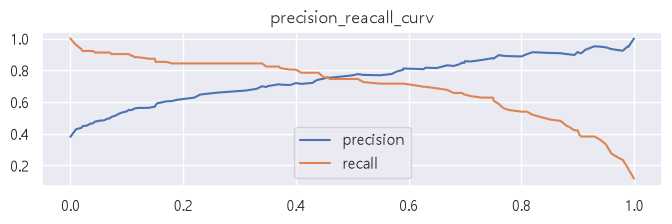

roc auc score : 0.8590


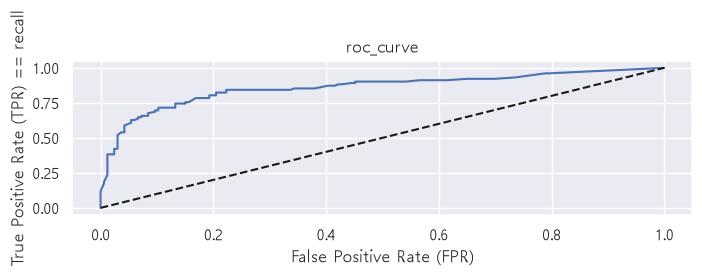

In [193]:
model = myscore222(traincp)

# **[8] 교차검증(CV) : 데이터증폭 + 튜닝**

* <font color=red><b> stratify 기능은 분류만 가능

```python
class sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

class sklearn.model_selection.StratifiedKFold(n_splits=5, *, shuffle=False, random_state=None)

class sklearn.model_selection.KFold(n_splits=5, *, shuffle=False, random_state=None)

class sklearn.model_selection.cross_val_score(estimator, X, y=None, *, groups=None, scoring=None, cv=None, n_jobs=None, verbose=0, params=None, pre_dispatch='2*n_jobs', error_score=nan)

sklearn.model_selection.cross_validate(estimator, X, y=None, *, groups=None, scoring=None, cv=None, n_jobs=None, verbose=0, params=None, pre_dispatch='2*n_jobs', return_train_score=False, return_estimator=False, return_indices=False, error_score=nan)


class sklearn.model_selection.GridSearchCV(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=KFold, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)

<img src="https://imghub.insilicogen.com/media/photos/cv.png" width=400>

In [194]:
train.shape

(891, 14)

In [195]:
891 / 5 

178.2

## **kFold()**

In [196]:
X = train.drop(columns=['survived'])
y = train['survived']

tot_acc = []
tot_f1  = []
kf = KFold(n_splits=5, shuffle=True, random_state=1234)
for train_idx, val_idx in kf.split(X):
    X_train = X.iloc[train_idx, :]
    y_train = y.iloc[train_idx]   
    X_val   = X.iloc[val_idx, :]
    y_val   = y.iloc[val_idx]
 
    model =  RandomForestClassifier (n_estimators=100,random_state=1234)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    
    acc       = accuracy_score(y_val, pred)
    f1        = f1_score(y_val, pred)
    print( f"acc : {acc:.4f}   f1 : {f1:.4f}" )
    tot_acc.append(acc)
    tot_f1.append(f1)
    
print( f"5회 평균 acc : {np.mean(tot_acc):.4f}   f1 : {np.mean(tot_f1):.4f}" )

acc : 0.8212   f1 : 0.7612
acc : 0.7865   f1 : 0.7031
acc : 0.8146   f1 : 0.7660
acc : 0.7865   f1 : 0.7031
acc : 0.8371   f1 : 0.7943
5회 평균 acc : 0.8092   f1 : 0.7455


## **StratifiedKFold()**
* <font color=red><b>kFold와 차이점 : 타겟(y)를 train,val에 골고루 섞어서 배분
* <font color=red><b>골고루?? 회귀사용불가  분류만가능

In [197]:
X = train.drop(columns=['survived'])
y = train['survived']

tot_acc = []
tot_f1  = []
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234) #---변경
for train_idx, val_idx in kf.split(X, y):   #-----kf.split(X)에서 y도 추가
    X_train = X.iloc[train_idx, :]
    y_train = y.iloc[train_idx]   
    X_val   = X.iloc[val_idx, :]
    y_val   = y.iloc[val_idx]
 
    model =  RandomForestClassifier (n_estimators=100,random_state=1234)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    
    acc       = accuracy_score(y_val, pred)
    f1        = f1_score(y_val, pred)
    print( f"acc : {acc:.4f}   f1 : {f1:.4f}" )
    tot_acc.append(acc)
    tot_f1.append(f1)
    
print( f"5회 평균 acc : {np.mean(tot_acc):.4f}   f1 : {np.mean(tot_f1):.4f}" )

acc : 0.8045   f1 : 0.7482
acc : 0.8034   f1 : 0.7518
acc : 0.7978   f1 : 0.7313
acc : 0.8034   f1 : 0.7287
acc : 0.7978   f1 : 0.7188
5회 평균 acc : 0.8013   f1 : 0.7357


## **cross_val_score()**
* kFold와 동일

In [198]:
X = train.drop(columns=['survived'])
y = train['survived']
model =  RandomForestClassifier (n_estimators=100,random_state=1234)

#kf = KFold(n_splits=5, shuffle=True, random_state=1234)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234) #---변경
tot_acc = cross_val_score(model, X, y, scoring="f1", cv=kf)
#tot_acc = cross_val_score(model, X, y, scoring="accuracy", cv=5)
print(tot_acc)
print(f"5회 평균 : {np.mean(tot_acc):.4f}")

[0.74820144 0.75177305 0.73134328 0.72868217 0.71875   ]
5회 평균 : 0.7357


## **cross_validate()**
* kFold와 동일

In [199]:
X = train.drop(columns=['survived'])
y = train['survived']
model =  RandomForestClassifier (n_estimators=300,random_state=1234)

#kf = KFold(n_splits=5, shuffle=True, random_state=1234)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234) #---변경
tot_dic = cross_validate(model, X, y, scoring=["accuracy","f1"], cv=kf)

tot_acc = tot_dic['test_accuracy'] 
tot_f1  = tot_dic['test_f1'] 
print(f"5회 평균 acc : {np.mean(tot_acc):.4f}")
print(f"5회 평균 f1 : {np.mean(tot_f1):.4f}")

5회 평균 acc : 0.8070
5회 평균 f1 : 0.7414


## **GridSearchCV()**
* <font color=red><b>증폭 + 튜닝
* 하이퍼 파라미터(hyper parameter) : 성능에 영향을 주는 파라미터 == 모델(이거이거)

``` python
RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)

In [200]:
X = train.drop(columns=['survived'])
y = train['survived']
model =  RandomForestClassifier (n_estimators=100,random_state=1234)
myparam = {"n_estimators"      : [100,200,300],
           "min_samples_split" : [2,3,4],
           "min_samples_leaf"  : [1,2,3]
          }

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1234)
gcv_model = GridSearchCV(model, param_grid=myparam, scoring="f1", refit=True, cv=kf)
gcv_model.fit(X, y)

print(gcv_model.best_params_)
print(gcv_model.best_score_)

{'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 100}
0.7802206689121679


* <b>refit=True 인 경우 bset_param으로 모델 재정의할 필요 없다

In [201]:
# model =  RandomForestClassifier (min_samples_leaf=3, min_samples_split=2, n_estimators=100)
# pred = model.predict(test)

* <font color=red><b>오버피팅 주의 주의주의주의

In [202]:
# 5회 평균 f1 : 0.7459   --->  0.7808

# **[9] Ensembles** : 모델결합
* Gradient boosting, random forests
* <font color=red><b>voting , bagging vs. boosting

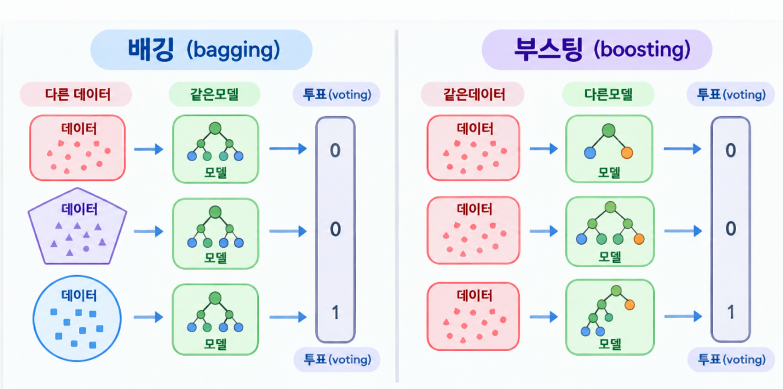

``` python
class sklearn.ensemble.VotingClassifier(estimators, *, voting='hard', weights=None, n_jobs=None, flatten_transform=True, verbose=False)

class sklearn.ensemble.VotingRegressor(estimators, *, weights=None, n_jobs=None, verbose=False)


* 배깅: 여러 개를 각각 → 합친다
* 부스팅: 하나 학습 → 틀린 부분 보완 → 또 학습 → 합친다

<table><thead><tr><th>구분</th><th><strong>배깅 (Bagging)<br>다른데이터,같은모델</strong></th><th><strong>부스팅 (Boosting)<br>같은데이터,다른모델</strong></th></tr></thead><tbody>
<tr><td>핵심 아이디어</td><td>N개 같은 모델을 <strong>독립적으로 학습</strong></td><td>N개 다른 모델을 <strong>순차적으로 학습</strong></td></tr>
<tr><td>학습 방식</td><td>병렬적</td><td>순차적</td></tr>
<tr><td>데이터</td><td>Bootstrap 샘플링</td><td>이전 모델의 오답에 집중</td></tr>
<tr><td>목적</td><td><strong>분산(Variance) 감소</strong></td><td><strong>편향(Bias) 감소</strong></td></tr>
<tr><td>모델 간 관계</td><td>서로 독립</td><td>이전 모델의 영향을 받음</td></tr>
<tr><td>과적합</td><td>상대적으로 강함</td><td>상대적으로 취약할 수 있음</td></tr>
<tr><td>대표 알고리즘</td><td><strong>Random Forest</strong></td><td><strong>AdaBoost, Gradient Boosting, XGBoost, LightGBM</strong></td></tr>
<tr><td>예측</td><td>여러 모델의 결과를 평균/투표</td><td>모델들을 순차적으로 결합</td></tr>
<tr><td>장점</td><td>안정적이고 과적합 방지에 유리</td><td>높은 예측 성능</td></tr>
<tr><td>단점</td><td>복잡한 패턴 학습에 한계</td><td>학습 시간이 길고 파라미터에 민감</td></tr>
</tbody></table>

In [203]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

In [204]:
X = train.drop(columns=['survived'])
y = train['survived']
X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234, shuffle=True)

model1 = LogisticRegression(max_iter=1000)
model2 = DecisionTreeClassifier(max_depth=3, random_state=42)
model3 = KNeighborsClassifier(n_neighbors=5)
vt_model = VotingClassifier(
    estimators=[
        ("lr"  , model1),
        ("dt"  , model2),
        ("knn" , model3)
    ],
    voting="hard"  #soft
)

vt_model.fit(X_train7, y_train7)
pred = vt_model.predict(X_test3)

#-------------------------------------------------pred
acc       = accuracy_score(y_test3, pred)
f1        = f1_score(y_test3, pred)  
print( f"acc : {acc:.4f}  f1 : {f1:.4f}" )

acc : 0.8433  f1 : 0.7857


# **[임계치 강제 조정]**
* Binarizer : Threshold를 OO으로 잡고, 보다크면 1로 이하는 0으로 바꿈

In [205]:
from sklearn.preprocessing import Binarizer

* <b>th : 0.0 기본

In [206]:
X = [[ 1., -1.,  2.],
     [ 2.,  0.,  0.],
     [ 0.,  1., -3.]]
bz = Binarizer(threshold=0.0)
bz.fit(X)
pred = bz.transform(X)
pred

array([[1., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

* <b>th : 1 기본

In [207]:
bz = Binarizer(threshold=1.0)
bz.fit(X)
pred = bz.transform(X)
pred

array([[0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 0.]])

In [208]:
bz = Binarizer(threshold=-1.3)
bz.fit(X)
pred = bz.transform(X)
pred

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 0.]])

In [209]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   name        891 non-null    int64  
 3   sex         891 non-null    int64  
 4   age         891 non-null    float64
 5   sibsp       891 non-null    int64  
 6   parch       891 non-null    int64  
 7   fare        891 non-null    float64
 8   embarked    891 non-null    float64
 9   age_group   891 non-null    float64
 10  family_cnt  891 non-null    int64  
 11  fare_rate   891 non-null    float64
 12  IsAlone     891 non-null    int64  
 13  FareBin     891 non-null    int64  
dtypes: float64(5), int64(9)
memory usage: 97.6 KB


In [210]:
X = train.drop(columns=['survived'])
y = train['survived']
X_train7, X_test3,    y_train7, y_test3 = train_test_split( X, y, test_size=0.3, random_state=1234, shuffle=True)

model = RandomForestClassifier(n_estimators=100,random_state=1234)
model.fit(X_train7, y_train7)
pred = model.predict(X_test3)

#-------------------------------------------------pred
acc       = accuracy_score(y_test3, pred)
f1        = f1_score(y_test3, pred)
precision = precision_score(y_test3, pred)
recall    = recall_score(y_test3, pred)    
print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )

cm = confusion_matrix(y_test3, pred)
print( cm )

#-------------------------------------------------proba
proba = model.predict_proba(X_test3)
proba_p = proba[:,1]


acc : 0.8284  f1 : 0.7723  precision : 0.7800  recall : 0.7647
[[144  22]
 [ 24  78]]


In [211]:
print( pred[:10])

[1 0 0 1 0 0 1 0 0 0]


In [212]:
print( proba[:10])

[[0.03       0.97      ]
 [0.98728571 0.01271429]
 [0.99       0.01      ]
 [0.04       0.96      ]
 [0.71       0.29      ]
 [0.83       0.17      ]
 [0.09333333 0.90666667]
 [0.74278846 0.25721154]
 [0.92       0.08      ]
 [0.55       0.45      ]]


In [213]:
bz = Binarizer(threshold=0.8)
bz.fit(proba_p.reshape(-1, 1) )
pred = bz.transform(proba_p.reshape(-1, 1) )
print(pred[:10])

[[1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]]


In [214]:
#-------------------------------------------------pred
acc       = accuracy_score(y_test3, pred)
f1        = f1_score(y_test3, pred)
precision = precision_score(y_test3, pred)
recall    = recall_score(y_test3, pred)    
print( f"acc : {acc:.4f}  f1 : {f1:.4f}  precision : {precision:.4f}  recall : {recall:.4f}" )

cm = confusion_matrix(y_test3, pred)
print( cm )

acc : 0.7985  f1 : 0.6707  precision : 0.8871  recall : 0.5392
[[159   7]
 [ 47  55]]


<pre>
th : 0.5
acc : 0.8097  f1 : 0.7463  precision : 0.7576  recall : 0.7353
[[142  24]
 [ 27  75]]

th : 0.1  : recall이 0.15점 상승
acc : 0.6567  f1 : 0.6618  precision : 0.5294  recall : 0.8824
[[86 80]
 [12 90]]

th : 0.9  : precision 0.13점 상승
acc : 0.7985  f1 : 0.6707  precision : 0.8871  recall : 0.5392
[[159   7]
 [ 47  55]]